# 08 — Faithfulness Baselines

**Question:** can the 12 difficulty-dimension scores predict whether the LLM will correctly judge a claim/evidence pair? This notebook establishes a few baselines to see whether the task is even feasible before investing in tuning.

**Target (y):** `pred_majority_correct` — 1 if the LLM (unconditioned Haiku, run 1) was correct on the majority of its 5 trials, else 0.

**Features (X):** the 12 fully-scored difficulty dimensions (`dim_SNs` is excluded because it is blank for most items).

**Four baselines:**
1. **Dummy** — ignores the features, always predicts the majority class. Any useful model must beat this.
2. **Logistic Regression** — linear, standardized features.
3. **Random Forest** — nonlinear, can capture interactions.
4. **Mean-threshold rule** — average the 12 dimension scores; if the average exceeds a threshold (default 2.5, i.e. "hard"), predict the LLM will **not** be correct (class 0).

**Leakage control:** the train/val/test split is grouped by `paperid`, so two pairs from the same paper never land in different splits. (More on other leakage risks at the end.)

## 1. Setup and data

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "scripts").exists() else cwd.parent
DATA = REPO_ROOT / "data" / "processed" / "faithfulness_dataset.parquet"
if not DATA.exists():
    raise FileNotFoundError(
        f"{DATA} not found. Build it first:\n  python scripts/build_faithfulness_dataset.py"
    )

df = pd.read_parquet(DATA)
print("loaded:", df.shape)
df.head(3)

loaded: (817, 29)


,item_id,source,paperid,claim_type,vtype,image_path,claim,label,dim_AS,dim_AT,...,dim_VL,dim_VO,pred_n_trials,pred_n_correct,pred_n_entailed,pred_frac_correct,pred_frac_entailed,pred_majority_correct,pred_majority_label,pred_unanimous
0,sciver_test_1,sciver,2409.06994v2,analytical,chart,/home/awndre/projects/Erdos/summer26-ai-scienc...,"In setting 10, increasing α from 0.0 to 0.3 re...",1,3.0,4.0,...,3.0,2.0,5,4,4,0.8,0.8,1,1,0
1,sciver_test_101,sciver,2410.02810v1,analytical,chart,/home/awndre/projects/Erdos/summer26-ai-scienc...,"At 30–40 steps, adding explicit state-tracking...",1,2.0,3.0,...,2.0,2.0,5,3,3,0.6,0.6,1,1,0
2,sciver_test_103,sciver,2410.11378v1,analytical,chart,/home/awndre/projects/Erdos/summer26-ai-scienc...,WPFed’s locality-sensitive hashing neighbor se...,1,3.0,3.0,...,2.0,2.0,5,2,2,0.4,0.4,0,0,0


## 2. Features, target, and groups

We use the 12 complete dimensions as features and confirm there are no missing values to trip up the models.

In [2]:
ALL_DIMS = [c for c in df.columns if c.startswith("dim_")]
FEATURES = [c for c in ALL_DIMS if c != "dim_SNs"]  # 12 complete dimensions
TARGET = "pred_majority_correct"
GROUP = "paperid"

print("n features:", len(FEATURES))
print(FEATURES)

X = df[FEATURES].to_numpy(dtype=float)
y = df[TARGET].to_numpy(dtype=int)
groups = df[GROUP].to_numpy()

assert not np.isnan(X).any(), "Unexpected NaNs in the 12 complete dimensions."
print("\nX:", X.shape, "| y:", y.shape)
print("class balance (1 = LLM mostly correct):", np.round(y.mean(), 3))

n features: 12
['dim_AS', 'dim_AT', 'dim_CL', 'dim_GS', 'dim_KNf', 'dim_MA', 'dim_MCr', 'dim_MCu', 'dim_QLl', 'dim_QLq', 'dim_VL', 'dim_VO']

X: (817, 12) | y: (817,)
class balance (1 = LLM mostly correct): 0.672


## 3. Group-aware train / val / test split

We split **by `paperid`** so no paper appears in more than one split. First carve off 20% of papers as the test set, then carve a validation set from what remains (~20% of the remainder). We then verify the paper groups are disjoint and check class balance per split.

In [3]:
# Step 1: hold out test papers.
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(X, y, groups))

# Step 2: split the remainder into train and val (also grouped).
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
tr_rel, val_rel = next(gss_val.split(X[trainval_idx], y[trainval_idx], groups[trainval_idx]))
train_idx = trainval_idx[tr_rel]
val_idx = trainval_idx[val_rel]

splits = {"train": train_idx, "val": val_idx, "test": test_idx}

# Verify no paper crosses splits (the whole point of grouping).
paper_sets = {name: set(groups[idx]) for name, idx in splits.items()}
assert not (paper_sets["train"] & paper_sets["val"]), "paper leak: train/val"
assert not (paper_sets["train"] & paper_sets["test"]), "paper leak: train/test"
assert not (paper_sets["val"] & paper_sets["test"]), "paper leak: val/test"

print(f"{'split':6s} {'items':>6s} {'papers':>7s} {'class1_rate':>12s}")
for name, idx in splits.items():
    print(f"{name:6s} {len(idx):6d} {len(paper_sets[name]):7d} {y[idx].mean():12.3f}")
print("\nNo paper appears in more than one split.")

split   items  papers  class1_rate
train     524     397        0.662
val       127     100        0.654
test      166     125        0.717

No paper appears in more than one split.


## 4. The custom mean-threshold model

A tiny scikit-learn-compatible classifier implementing your rule: average the (raw) dimension scores for a pair; if the average is above `threshold`, predict the LLM will **not** be correct (class 0), otherwise predict correct (class 1). `fit` doesn't learn anything from the data — the rule is fixed — which makes it a transparent, interpretable baseline.

In [4]:
class MeanThresholdClassifier(BaseEstimator, ClassifierMixin):
    """Predict class 0 (LLM not correct) when the mean feature score exceeds `threshold`."""

    def __init__(self, threshold=2.5):
        self.threshold = threshold

    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1])
        return self

    def _mean(self, X):
        return np.asarray(X, dtype=float).mean(axis=1)

    def decision_function(self, X):
        # Higher score -> more confident in class 1 (easy item). Used for ROC-AUC.
        return self.threshold - self._mean(X)

    def predict(self, X):
        return (self._mean(X) <= self.threshold).astype(int)

## 5. Define models and an evaluation helper

Logistic regression standardizes its inputs inside a `Pipeline`, so the scaler is fit on training data only (no preprocessing leakage). Logistic regression and random forest use balanced class weights because the target is imbalanced (~67% positive).

In [5]:
models = {
    "Dummy (majority)": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "MeanThreshold(2.5)": MeanThresholdClassifier(threshold=2.5),
}


def get_scores(model, X):
    """Continuous scores for ROC-AUC: predict_proba if available, else decision_function."""
    if hasattr(model, "predict_proba"):
        try:
            return model.predict_proba(X)[:, 1]
        except Exception:
            pass
    if hasattr(model, "decision_function"):
        try:
            return model.decision_function(X)
        except Exception:
            pass
    return None


def evaluate(model, X, y):
    pred = model.predict(X)
    scores = get_scores(model, X)
    auc = np.nan
    if scores is not None and len(np.unique(y)) == 2 and np.ptp(scores) > 0:
        auc = roc_auc_score(y, scores)
    return {
        "accuracy": accuracy_score(y, pred),
        "balanced_acc": balanced_accuracy_score(y, pred),
        "f1_macro": f1_score(y, pred, average="macro"),
        "roc_auc": auc,
    }

## 6. Train and compare on the validation set

Fit each model on the training set and score it on validation. Use this table to compare baselines; the test set is reserved for a final, untouched check.

In [6]:
X_tr, y_tr = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_te, y_te = X[test_idx], y[test_idx]

for model in models.values():
    model.fit(X_tr, y_tr)

val_results = pd.DataFrame({name: evaluate(m, X_val, y_val) for name, m in models.items()}).T
val_results.round(3)

,accuracy,balanced_acc,f1_macro,roc_auc
Dummy (majority),0.654,0.500,0.395,NaN
LogisticRegression,0.512,0.520,0.503,0.520
RandomForest,0.575,0.493,0.485,0.437
MeanThreshold(2.5),0.575,0.466,0.436,0.503


## 7. Tune the threshold on validation (optional, principled)

Your rule fixed the threshold at 2.5. Here we instead pick the threshold that maximizes balanced accuracy **on the validation set** — never the test set — to give the rule a fair shot.

In [7]:
candidate_thresholds = np.round(np.arange(1.0, 4.05, 0.1), 2)
best_t, best_score = 2.5, -1.0
for t in candidate_thresholds:
    m = MeanThresholdClassifier(threshold=t).fit(X_tr, y_tr)
    s = balanced_accuracy_score(y_val, m.predict(X_val))
    if s > best_score:
        best_t, best_score = t, s
print(f"best threshold on val: {best_t} (balanced_acc={best_score:.3f})")
models[f"MeanThreshold(val={best_t})"] = MeanThresholdClassifier(threshold=best_t).fit(X_tr, y_tr)

best threshold on val: 1.6 (balanced_acc=0.553)


## 8. Final evaluation on the held-out test set

Report every model on the test set, plus confusion matrices. Compare against the Dummy row: a model is only useful if it clearly beats the majority-class baseline (especially on **balanced accuracy** and **ROC-AUC**, which are not fooled by class imbalance).

In [8]:
test_results = pd.DataFrame({name: evaluate(m, X_te, y_te) for name, m in models.items()}).T
print("TEST results:")
test_results.round(3)

TEST results:


,accuracy,balanced_acc,f1_macro,roc_auc
Dummy (majority),0.717,0.500,0.418,NaN
LogisticRegression,0.608,0.592,0.571,0.609
RandomForest,0.663,0.559,0.561,0.569
MeanThreshold(2.5),0.645,0.475,0.448,0.451
MeanThreshold(val=1.6),0.337,0.448,0.335,0.451


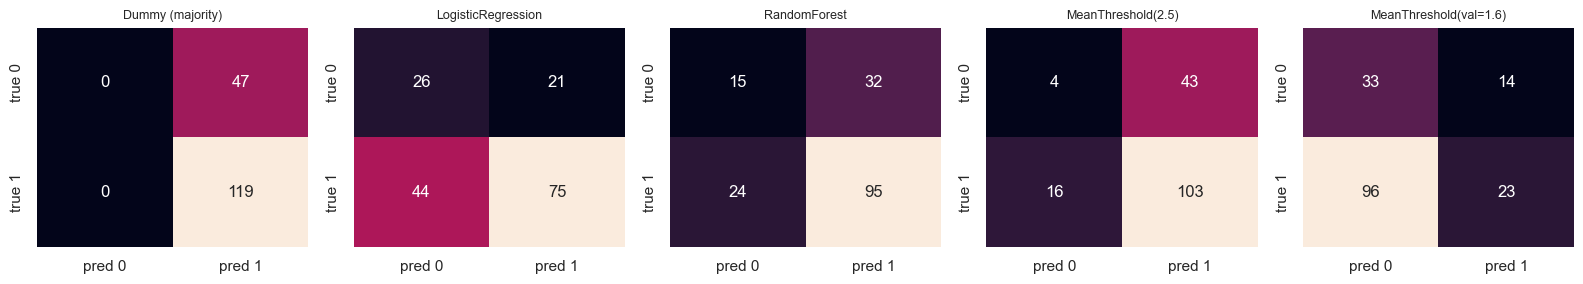

In [9]:
n = len(models)
fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3))
for ax, (name, m) in zip(np.atleast_1d(axes), models.items()):
    cm = confusion_matrix(y_te, m.predict(X_te), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, ax=ax,
                xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.show()

## 9. Data leakage — what we guarded against, and what else to watch

**Handled here**

- **Group (paper) leakage** — split by `paperid` via `GroupShuffleSplit`, verified disjoint. Pairs from the same paper share figures/topics, so letting them straddle train/test would inflate scores.
- **Preprocessing leakage** — the `StandardScaler` lives *inside* the logistic-regression `Pipeline`, so it is fit on the training fold only, never on val/test.
- **Threshold/hyperparameter leakage** — the mean-threshold tuning uses the **validation** set only; the test set is touched exactly once, at the end.

**Other risks worth checking**

- **Feature/target provenance** — the difficulty scores were produced by a *different* model/process (Sonnet annotations) than the prediction LLM (Haiku, run 1). Good: features are not derived from the target. Keep it that way — never feed any `pred_*` column in as a feature.
- **Duplicate / near-duplicate claims across papers** — grouping by paper catches same-paper repeats, but identical claims reused across papers would still leak. Worth a quick check (exact-duplicate `claim` text spanning splits) if you later add text features.
- **SciVer val/test origin** — items come from SciVer's own val+test; if you ever join back to SciVer-derived features, respect those original splits too.
- **Tiny groups** — most papers have 1 item (max 2), so grouped K-fold cross-validation would give more stable estimates than a single split. Consider `GroupKFold` next.

## Next steps

- If a real model clearly beats Dummy, the task looks feasible — move to `GroupKFold` cross-validation for stabler estimates and light hyperparameter tuning.
- Revisit `dim_SNs`: try imputation or a separate model on the 200 items that have it.
- Add metadata features (`claim_type`, `vtype`) and inspect per-class errors, since the LLM is much better on refuted than entailed items.